# Modeling of Employee Skill Demand Evolution in the US using Dynamic Topic Modeling and Embedding Models
Data Practicum 1 Project


## Package Installations

In [1]:
!pip uninstall -y sentence-transformers transformers accelerate peft
!pip install "transformers==4.38.2" "sentence-transformers==2.6.1" "accelerate==0.27.2" "peft==0.8.2"

Found existing installation: sentence-transformers 5.2.3
Uninstalling sentence-transformers-5.2.3:
  Successfully uninstalled sentence-transformers-5.2.3
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━

In [2]:
!pip install --no-cache-dir --upgrade "scikit-learn==1.4.2"
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 80.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 52.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2


# Getting Datasets

## US Job Listing Data

In [ ]:
import requests
import pandas as pd
from datetime import datetime

# Setting API Key
api_key = "********************************************"

# Getting API URL
url = "https://data.usajobs.gov/api/historicjoa"

# Extracting the API data
response = requests.get(url)
usa_jobs_data = response.json()

# Getting overview of API data structure
print(type(usa_jobs_data))
print(type(usa_jobs_data["data"]))


# Extracting job records
usa_jobs_data = usa_jobs_data["data"]

# Converting to DataFrame
usa_jobs_data = pd.DataFrame(usa_jobs_data)

# Getting Data Overview
usa_jobs_data.head()

<class 'dict'>
<class 'list'>


,usajobsControlNumber,hiringAgencyCode,hiringAgencyName,hiringDepartmentCode,hiringDepartmentName,agencyLevel,agencyLevelSort,appointmentType,workSchedule,payScale,...,maximumSalary,supervisoryStatus,drugTestRequired,relocationExpensesReimbursed,totalOpenings,disableAppyOnline,positionOpeningStatus,hiringpaths,jobcategories,positionlocations
0,1282412,ARTA,U.S. Army Recruiting Command and U.S. Army Cad...,AR,Department of the Army,2,Department of the Army\U.S. Army Recruiting Co...,Permanent,Full-time,YA,...,70843.0,N,N,N,None,Y,Applications under review,[{'hiringPath': 'Federal employees - Competiti...,[{'series': '0560'}],"[{'positionLocationCity': 'Fayetteville', 'pos..."
1,302858300,DJ01,"Offices, Boards and Divisions",DJ,Department of Justice,2,"Department of Justice\Offices, Boards and Divi...",Multiple,Full-time,GS,...,129517.0,N,N,N,Many,N,Applications under review,[{'hiringPath': 'The public'}],[{'series': '0905'}],"[{'positionLocationCity': 'Washington', 'posit..."
2,309472900,TRAD,U.S. Mint,TR,Department of the Treasury,2,Department of the Treasury\U.S. Mint,Permanent,Full-time,GS,...,115742.0,N,N,N,None,N,Applications under review,[{'hiringPath': 'The public'}],[{'series': '2210'}],"[{'positionLocationCity': 'Washington', 'posit..."
3,309482600,TRAD,U.S. Mint,TR,Department of the Treasury,2,Department of the Treasury\U.S. Mint,Permanent,Full-time,GS,...,115742.0,N,N,N,None,N,Applications under review,[{'hiringPath': 'Federal employees - Competiti...,[{'series': '2210'}],"[{'positionLocationCity': 'Washington', 'posit..."
4,314527500,VALA,Veterans Benefits Administration,VA,Department of Veterans Affairs,2,Department of Veterans Affairs\Veterans Benefi...,Agency Employees Only,Full-time,GS,...,0.0,N,N,N,None,N,Applications under review,[{'hiringPath': 'The public'}],[{'series': '0996'}],"[{'positionLocationCity': 'Jackson', 'position..."


In [4]:
# Checking structure of data
print(usa_jobs_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   usajobsControlNumber                500 non-null    int64  
 1   hiringAgencyCode                    500 non-null    object 
 2   hiringAgencyName                    498 non-null    object 
 3   hiringDepartmentCode                500 non-null    object 
 4   hiringDepartmentName                500 non-null    object 
 5   agencyLevel                         500 non-null    int64  
 6   agencyLevelSort                     500 non-null    object 
 7   appointmentType                     500 non-null    object 
 8   workSchedule                        500 non-null    object 
 9   payScale                            500 non-null    object 
 10  salaryType                          500 non-null    object 
 11  vendor                              500 non-n

In [5]:
# Checking Data Completeness
print(usa_jobs_data.isnull().sum())

usajobsControlNumber                    0
hiringAgencyCode                        0
hiringAgencyName                        2
hiringDepartmentCode                    0
hiringDepartmentName                    0
agencyLevel                             0
agencyLevelSort                         0
appointmentType                         0
workSchedule                            0
payScale                                0
salaryType                              0
vendor                                  0
travelRequirement                     118
teleworkEligible                        0
serviceType                           495
securityClearanceRequired               0
securityClearance                      37
whoMayApply                             5
announcementClosingTypeCode           495
announcementClosingTypeDescription    495
positionOpenDate                        0
positionCloseDate                       0
positionExpireDate                    187
announcementNumber                

In [6]:
# Subsetting the data to retain only relevant variables with full information
usa_jobs_subset = usa_jobs_data[["positionOpenDate", "positionTitle", "appointmentType", "maximumSalary", "workSchedule", "salaryType", "positionlocations"]]
# Getting Subset overview
usa_jobs_subset.head()

,positionOpenDate,positionTitle,appointmentType,maximumSalary,workSchedule,salaryType,positionlocations
0,2020-07-22,BUDGET ANALYST,Permanent,70843.0,Full-time,Per Year,"[{'positionLocationCity': 'Fayetteville', 'pos..."
1,2013-09-11,Attorney and Assistant United States Attorney,Multiple,129517.0,Full-time,Per Year,"[{'positionLocationCity': 'Washington', 'posit..."
2,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,"[{'positionLocationCity': 'Washington', 'posit..."
3,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,"[{'positionLocationCity': 'Washington', 'posit..."
4,2018-02-15,Rating Veterans Service Representative,Agency Employees Only,0.0,Full-time,Per Year,"[{'positionLocationCity': 'Jackson', 'position..."


In [7]:
# Inspecting the PositionLocation list variable
usa_jobs_subset.positionlocations[1]

[{'positionLocationCity': 'Washington',
  'positionLocationState': 'District of Columbia',
  'positionLocationCountry': 'United States'}]

In [8]:
# Delisting the PositionLocation variable and retaining the state attribute
usa_jobs_subset["state"] = usa_jobs_subset["positionlocations"].apply(
    lambda x: x[0]["positionLocationState"] if isinstance(x, list) and len(x) > 0 else None
)

usa_jobs_subset = usa_jobs_subset.drop(columns=["positionlocations"])
# Getting Subset overview
usa_jobs_subset.head()

/tmp/ipykernel_216/490016046.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usa_jobs_subset["state"] = usa_jobs_subset["positionlocations"].apply(


,positionOpenDate,positionTitle,appointmentType,maximumSalary,workSchedule,salaryType,state
0,2020-07-22,BUDGET ANALYST,Permanent,70843.0,Full-time,Per Year,North Carolina
1,2013-09-11,Attorney and Assistant United States Attorney,Multiple,129517.0,Full-time,Per Year,District of Columbia
2,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,District of Columbia
3,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,District of Columbia
4,2018-02-15,Rating Veterans Service Representative,Agency Employees Only,0.0,Full-time,Per Year,Mississippi


## US Federal Payroll Data

In [9]:
import requests
import pandas as pd

# URL for Accessing Payroll Data through API
url = (
    "https://api.census.gov/data/timeseries/govs"
    "?get=group(GS00EP01)"
    "&time=2024"
    "&SVY_COMP=01"
    "&GOVTYPE=001"
    "&AGG_DESC=EP0005"
    "&AGG_DESC=EP0045"
    "&AGG_DESC=EP0085"
    "&AGG_DESC=EP0125"
    "&AGG_DESC=EP0165"
    "&AGG_DESC=EP0205"
    "&AGG_DESC=EP0245"
    "&AGG_DESC=EP0285"
    "&AGG_DESC=EP0325"
    "&AGG_DESC=EP0365"
    "&AGG_DESC=EP0405"
    "&AGG_DESC=EP0445"
    "&AGG_DESC=EP0485"
    "&AGG_DESC=EP0525"
    "&AGG_DESC=EP0565"
    "&AGG_DESC=EP0605"
    "&AGG_DESC=EP0645"
    "&AGG_DESC=EP0685"
    "&AGG_DESC=EP0725"
    "&AGG_DESC=EP0765"
    "&AGG_DESC=EP0805"
    "&AGG_DESC=EP0845"
    "&AGG_DESC=EP0885"
    "&AGG_DESC=EP0925"
    "&AGG_DESC=EP0965"
    "&AGG_DESC=EP1005"
    "&AGG_DESC=EP1045"
    "&AGG_DESC=EP1085"
    "&AGG_DESC=EP1125"
    "&AGG_DESC=EP1165"
    "&AGG_DESC=EP1205"
    "&AGG_DESC=EP1245"
    "&AGG_DESC=EP1285"
    "&AGG_DESC=EP1325"
    "&AGG_DESC=EP1365"
    "&AGG_DESC=EP1405"
    "&AGG_DESC=EP1445"
    "&AGG_DESC=EP1485"
    "&ucgid=0100000US"
)


In [10]:
# Getting data from URL
response = requests.get(url)

# JSON Data Format and Overview
payroll_data = response.json()
print(payroll_data[:3])
print(len(payroll_data))


[['AGG_DESC', 'AGG_DESC_LABEL', 'FTE', 'FTE_F', 'FTE_CV', 'FTE_CV_F', 'FT_EMP', 'FT_EMP_F', 'FT_EMP_CV', 'FT_EMP_CV_F', 'FT_PAY', 'FT_PAY_F', 'FT_PAY_CV', 'FT_PAY_CV_F', 'GEO_ID', 'GEO_ID_F', 'NAME', 'GOVTYPE', 'GOVTYPE_LABEL', 'PT_EMP', 'PT_EMP_F', 'PT_EMP_CV', 'PT_EMP_CV_F', 'PT_HRS', 'PT_HRS_F', 'PT_HRS_CV', 'PT_HRS_CV_F', 'PT_PAY', 'PT_PAY_F', 'PT_PAY_CV', 'PT_PAY_CV_F', 'SVY_COMP', 'SVY_COMP_LABEL', 'TOT_EMP', 'TOT_EMP_F', 'TOT_EMP_CV', 'TOT_EMP_CV_F', 'TOT_PAY', 'TOT_PAY_F', 'TOT_PAY_CV', 'TOT_PAY_CV_F', 'YEAR', 'time', 'SVY_COMP', 'GOVTYPE', 'AGG_DESC', 'ucgid'], ['EP0005', 'Total - All Government Employment Functions', '17168870', None, '0.08', None, '15441814', None, '0.09', None, '99306766254', None, '0.10', None, '0100000US', None, 'United States', '001', 'State and Local', '4488676', None, '0.05', None, '0', 'N', '0.00', 'N', '7923899757', None, '0.05', None, '01', 'Annual Survey of Public Employment & Payroll', '19930490', None, '0.07', None, '107230666011', None, '0.09', 

In [11]:
# Preparing pandas DataFrame
headers = payroll_data[0]
values = payroll_data[1:]

payroll_df = pd.DataFrame(values, columns=headers)
payroll_df.head()


,AGG_DESC,AGG_DESC_LABEL,FTE,FTE_F,FTE_CV,FTE_CV_F,FT_EMP,FT_EMP_F,FT_EMP_CV,FT_EMP_CV_F,...,TOT_PAY,TOT_PAY_F,TOT_PAY_CV,TOT_PAY_CV_F,YEAR,time,SVY_COMP,GOVTYPE,AGG_DESC,ucgid
0,EP0005,Total - All Government Employment Functions,17168870,None,0.08,None,15441814,None,0.09,None,...,107230666011,None,0.09,None,2024,2024,01,001,EP0005,0100000US
1,EP0045,Financial Administration,436914,None,0.09,None,417921,None,0.10,None,...,2869221109,None,0.10,None,2024,2024,01,001,EP0045,0100000US
2,EP0085,Other Government Administration,291458,None,0.16,None,260754,None,0.17,None,...,1897763526,None,0.15,None,2024,2024,01,001,EP0085,0100000US
3,EP0125,Judicial and Legal,428922,None,0.12,None,413061,None,0.12,None,...,3024123166,None,0.07,None,2024,2024,01,001,EP0125,0100000US
4,EP0165,Police Protection Total,952690,None,0.12,None,918473,None,0.12,None,...,7662986603,None,0.14,None,2024,2024,01,001,EP0165,0100000US


In [12]:
# Checking Data Completeness
payroll_df.isnull().sum()

,0
AGG_DESC,0
AGG_DESC_LABEL,0
FTE,0
FTE_F,38
FTE_CV,0
FTE_CV_F,38
FT_EMP,0
FT_EMP_F,38
FT_EMP_CV,0
FT_EMP_CV_F,38


In [13]:
# Removing columns with null entries
payroll_df = payroll_df.dropna(axis=1)

In [14]:
# Saving final payroll data
payroll_df.to_csv("payroll_df.csv", index=False)

## National Labor Statistics Data

In [15]:
import json

# URL for Accessing Labor Statistics Data through API
url = "https://api.bls.gov/publicAPI/v1/timeseries/data/"

# Specifying the unemployment rate and total private average earnings for all employees
series_ids = ["LNS14000000", "CES0500000003"]

# Building the payload for API
payload = {
    "seriesid": series_ids,
    "startyear": "2015",
    "endyear": "2024"
}

# Getting Data from API
response = requests.post(url, json=payload)
response.raise_for_status()


In [16]:
# JSON format data
labor_data = response.json()

# Data Overview
for series in labor_data["Results"]["series"]:
    print(f"Series: {series['seriesID']}")
    for item in series["data"]:
        print(item["year"], item["period"], item["value"])
    print()


Series: LNS14000000
2024 M12 4.1
2024 M11 4.2
2024 M10 4.1
2024 M09 4.1
2024 M08 4.2
2024 M07 4.2
2024 M06 4.1
2024 M05 3.9
2024 M04 3.9
2024 M03 3.9
2024 M02 3.9
2024 M01 3.7
2023 M12 3.8
2023 M11 3.7
2023 M10 3.9
2023 M09 3.7
2023 M08 3.7
2023 M07 3.5
2023 M06 3.6
2023 M05 3.6
2023 M04 3.4
2023 M03 3.5
2023 M02 3.6
2023 M01 3.5
2022 M12 3.5
2022 M11 3.6
2022 M10 3.6
2022 M09 3.5
2022 M08 3.6
2022 M07 3.5
2022 M06 3.6
2022 M05 3.6
2022 M04 3.7
2022 M03 3.7
2022 M02 3.9
2022 M01 4.0
2021 M12 3.9
2021 M11 4.1
2021 M10 4.5
2021 M09 4.7
2021 M08 5.1
2021 M07 5.4
2021 M06 5.9
2021 M05 5.8
2021 M04 6.1
2021 M03 6.1
2021 M02 6.2
2021 M01 6.4
2020 M12 6.7
2020 M11 6.7
2020 M10 6.9
2020 M09 7.8
2020 M08 8.4
2020 M07 10.2
2020 M06 11.0
2020 M05 13.2
2020 M04 14.8
2020 M03 4.4
2020 M02 3.5
2020 M01 3.6
2019 M12 3.6
2019 M11 3.6
2019 M10 3.6
2019 M09 3.5
2019 M08 3.6
2019 M07 3.7
2019 M06 3.6
2019 M05 3.6
2019 M04 3.7
2019 M03 3.8
2019 M02 3.8
2019 M01 4.0
2018 M12 3.9
2018 M11 3.8
2018 M10 3.8
2

In [17]:
# Converting from JSON format to Pandas
labor_df = []

for series in labor_data["Results"]["series"]:
    sid = series["seriesID"]
    for item in series["data"]:
        labor_df.append({
            "series_id": sid,
            "year": int(item["year"]),
            "period": item["period"],
            "value": float(item["value"])
        })

labor_df = pd.DataFrame(labor_df)
labor_df.head()

,series_id,year,period,value
0,LNS14000000,2024,M12,4.1
1,LNS14000000,2024,M11,4.2
2,LNS14000000,2024,M10,4.1
3,LNS14000000,2024,M09,4.1
4,LNS14000000,2024,M08,4.2


In [18]:
# Renaming the series id with series name
series_map = {
    "LNS14000000": "unemployment_rate",
    "CES0500000003": "avg_hourly_earnings"
}

labor_df["series_id"] = labor_df["series_id"].map(series_map)
labor_df.head()

,series_id,year,period,value
0,unemployment_rate,2024,M12,4.1
1,unemployment_rate,2024,M11,4.2
2,unemployment_rate,2024,M10,4.1
3,unemployment_rate,2024,M09,4.1
4,unemployment_rate,2024,M08,4.2


In [19]:
# Saving final labor data
labor_df.to_csv("labor_df.csv", index=False)

## New York City Data

In [20]:
import requests
import pandas as pd

# API URL
url = "https://data.cityofnewyork.us/resource/k397-673e.json"

# Requesting Data from API
response = requests.get(url)

# JSON Data Format
city_data = response.json()

# Converting to Pandas format
city_df = pd.DataFrame(city_data)
# Data Overview
city_df

,fiscal_year,payroll_number,agency_name,last_name,first_name,agency_start_date,work_location_borough,title_description,leave_status_as_of_june_30,base_salary,pay_basis,regular_hours,regular_gross_paid,ot_hours,total_ot_paid,total_other_pay,mid_init
0,2025,67,ADMIN FOR CHILDREN'S SVCS,TAYLOR,DENISE,2006-09-04T00:00:00.000,MANHATTAN,SUPERVISOR II,ACTIVE,80632.00,per Annum,1820.00,78118.64,27.50,1522.72,5081.35,NaN
1,2025,67,ADMIN FOR CHILDREN'S SVCS,MENCIA,EDWIN,1998-03-09T00:00:00.000,MANHATTAN,EXECUTIVE ASSISTANT TO THE EXECUTIVE DEPUTY ADM,ACTIVE,142829.00,per Annum,1820.00,132898.25,0.00,0.00,5293.35,A
2,2025,67,ADMIN FOR CHILDREN'S SVCS,CALIM,SALIMIE,1996-06-23T00:00:00.000,MANHATTAN,CHILD PROTECTIVE SPECIALIST SUPERVISOR,CEASED,97327.00,per Annum,952.00,50922.84,0.00,0.00,2640.10,NaN
3,2025,67,ADMIN FOR CHILDREN'S SVCS,BIRKETT,LESLIE,1997-07-06T00:00:00.000,MANHATTAN,SUPERVISOR II,ACTIVE,80491.00,per Annum,1820.00,77981.47,0.00,0.00,5054.29,NaN
4,2025,67,ADMIN FOR CHILDREN'S SVCS,NEALY,DWAYNE,1996-06-23T00:00:00.000,MANHATTAN,CHILD PROTECTIVE SPECIALIST,ON SEPARATION LEAVE,70264.00,per Annum,1820.00,68070.52,300.75,15891.17,12663.10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025,67,ADMIN FOR CHILDREN'S SVCS,BENNETT,FAYETTE,1997-10-06T00:00:00.000,MANHATTAN,ADMINISTRATIVE DIRECTOR OF SOCIAL SERVICES,ACTIVE,164055.00,per Annum,1820.00,158437.86,0.00,0.00,0.00,NaN
996,2025,67,ADMIN FOR CHILDREN'S SVCS,RUSSO,STACEY,1997-10-06T00:00:00.000,MANHATTAN,ADMINISTRATIVE DIRECTOR OF SOCIAL SERVICES,ACTIVE,102602.00,per Annum,1820.00,99431.63,0.00,0.00,699.41,A
997,2025,67,ADMIN FOR CHILDREN'S SVCS,DANIELS,SHARYN,1997-10-06T00:00:00.000,MANHATTAN,PRINCIPAL ADMINISTRATIVE ASSOCIATE - NON SUPVR,ACTIVE,76731.00,per Annum,1820.00,75395.97,0.00,0.00,4706.33,M
998,2025,67,ADMIN FOR CHILDREN'S SVCS,HENDERSON,ERIC,2019-02-04T00:00:00.000,BROOKLYN,CHILD PROTECTIVE SPECIALIST,CEASED,64001.00,per Annum,0.00,0.00,0.00,0.00,649.22,Z


In [21]:
# Saving final city data
city_df.to_csv("city_df.csv", index=False)

# Definition of Functions

## Natural Language Processing (NLP Function)

In [22]:
# Text Data Preparation for Topic Modeling
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Identifying stopwords
english_stopwords = set(stopwords.words('english'))
custom_stopwords = {
    'test','announcement', 'assignment','general','contract','direct','hire','open','continuous','recent','graduate','pathways','census','military',
    'requirement','equivalent','status','external','deu','mp','esep','map','dh','nc','locum','prn', 'program', 'non', 'acs', 'admin', 'adm', 'child',
    'family', 'field', 'youth', 'congreg', 'spec', 'iii', 'availability'
}
hierarchy_words = {
    'director','deputy','assistant','associate','principal','senior','junior','chief','lead','supervisor', 'mgrl',
    'manager','officer','coordinator','staff','specialist','analyst','agent','administrator', 'inspector', 'supvr'
}
location_words = {
    'new','york','nyc','los','angeles','chicago','boston','washington','dc','texas','california','county','city',
    'state','department','agency'
}
structural_words = {
    'total','other','all','unallocable','services'
}

# Combining all stopwords
all_stopwords = (
    english_stopwords
    .union(custom_stopwords)
    .union(hierarchy_words)
    .union(location_words)
    .union(structural_words)
)

# Function for cleaning the test data
def fxn_clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    # Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove stopwords + short tokens
    cleaned = [
        word for word in text.split()
        if word not in all_stopwords and len(word) > 2
    ]

    return ' '.join(cleaned)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## LDA Topics Plotting Function

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Function for ploting LDA topics
def fxn_plot_lda_topics(model, feature_names, n_top_words=8):
    n_topics = model.n_components
    fig, axes = plt.subplots(n_topics, 1, figsize=(10, 2.5 * n_topics))

    for i, ax in enumerate(axes):
        top_features = model.components_[i].argsort()[:-n_top_words-1:-1]
        weights = model.components_[i][top_features]
        words = [feature_names[j] for j in top_features]

        ax.barh(words[::-1], weights[::-1])
        ax.set_title(f"Skill_Set_(Topic) {i}")
        ax.set_xlabel("Word weight")

    plt.tight_layout()
    plt.show()

## Keywords Extraction Function

In [24]:
# Using the keywords disctionary to extract the keywords for each of the topics

def get_topic_keywords(model, feature_names, n_top_words=5):
    topic_keywords = {}

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words-1:-1]
        top_words = [feature_names[i] for i in top_indices]
        topic_keywords[topic_idx] = " ".join(top_words)

    return topic_keywords

## LDA Topics Embedding Function

In [25]:
# Scaling the probabilities for each topic and attaching the dominant key words to each job position

def build_skill_text(row):
    return (
        topic_keywords[0] * int(row['skill_set_0'] * 5) + " " +
        topic_keywords[1] * int(row['skill_set_1'] * 5) + " " +
        topic_keywords[2] * int(row['skill_set_2'] * 5)
    )


# US JOBS CASE


## Natural Language Processing (NLP)

In [26]:
# Cleaning Text Data
usa_jobs_subset['clean_positionTitle'] = usa_jobs_subset['positionTitle'].apply(fxn_clean_text)

## Topic Modelling

In [27]:
# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Converting text to bag-of-words format
vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(usa_jobs_subset['clean_positionTitle'])

# Fitting LDA model for 3 topics
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(bow)

# Function for getting overview of resultant topics
def fxn_display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print({topic_idx},":", [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]])

# Getting topics for all the job titles
fxn_display_topics(lda_model, vectorizer.get_feature_names_out(), 5)

{0} : ['aviation', 'safety', 'nurse', 'management', 'operations']
{1} : ['supervisory', 'engineer', 'service', 'scientist', 'human']
{2} : ['physician', 'medical', 'technician', 'care', 'support']


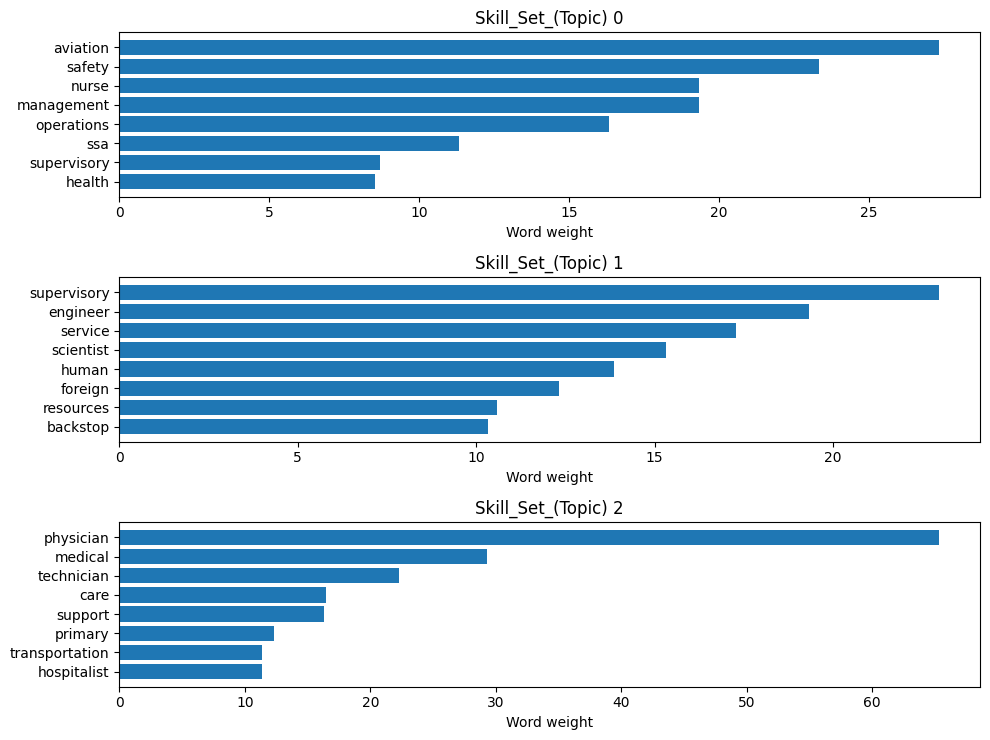

In [28]:
# Plotting LDA topic
fxn_plot_lda_topics(lda_model, vectorizer.get_feature_names_out())

### Dynamic Topic Modelling

In [29]:
# Transforming titles into topic probability distributions
topic_distributions = lda_model.transform(bow)

# Adding topics to data
n_topics = topic_distributions.shape[1]

for i in range(n_topics):
    usa_jobs_subset[f"skill_set_{i}"] = topic_distributions[:, i]

# Data overview
usa_jobs_subset.head()

,positionOpenDate,positionTitle,appointmentType,maximumSalary,workSchedule,salaryType,state,clean_positionTitle,skill_set_0,skill_set_1,skill_set_2
0,2020-07-22,BUDGET ANALYST,Permanent,70843.0,Full-time,Per Year,North Carolina,budget,0.666335,0.166842,0.166823
1,2013-09-11,Attorney and Assistant United States Attorney,Multiple,129517.0,Full-time,Per Year,District of Columbia,attorney united states attorney,0.067013,0.066984,0.866004
2,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,District of Columbia,information technology data network,0.458469,0.474677,0.066854
3,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,District of Columbia,information technology data network,0.458469,0.474677,0.066854
4,2018-02-15,Rating Veterans Service Representative,Agency Employees Only,0.0,Full-time,Per Year,Mississippi,rating veterans service representative,0.066846,0.865790,0.067364


In [30]:
# Setting datetime format for positionOpenDate
usa_jobs_subset['positionOpenDate'] = pd.to_datetime(
    usa_jobs_subset['positionOpenDate']
)


# Creating year-month column
usa_jobs_subset['year_month'] = usa_jobs_subset['positionOpenDate'].dt.to_period('M')
print(usa_jobs_subset.head())

# Aggregating mean skill probabilities by year-month
skill_trends = usa_jobs_subset.groupby('year_month')[
    ['skill_set_0', 'skill_set_1', 'skill_set_2']
].mean()

# Converting Index to timestamp
skill_trends.index = skill_trends.index.to_timestamp()

print(skill_trends.head())


  positionOpenDate                                      positionTitle  \
0       2020-07-22                                     BUDGET ANALYST   
1       2013-09-11      Attorney and Assistant United States Attorney   
2       2020-02-14  SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...   
3       2020-02-14  SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...   
4       2018-02-15             Rating Veterans Service Representative   

         appointmentType  maximumSalary workSchedule salaryType  \
0              Permanent        70843.0    Full-time   Per Year   
1               Multiple       129517.0    Full-time   Per Year   
2              Permanent       115742.0    Full-time   Per Year   
3              Permanent       115742.0    Full-time   Per Year   
4  Agency Employees Only            0.0    Full-time   Per Year   

                  state                     clean_positionTitle  skill_set_0  \
0        North Carolina                                  budget     0.666335  

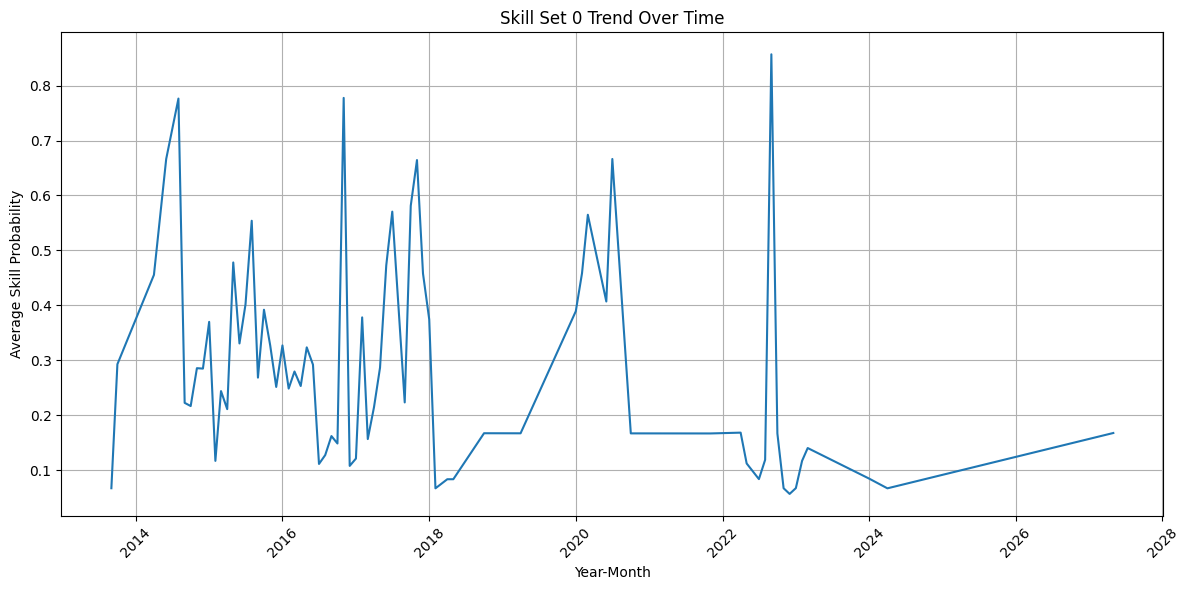

In [31]:
# Dynamic Topic Model Plot

# Skill Set 0
plt.figure(figsize=(12, 6))
plt.plot(skill_trends.index, skill_trends['skill_set_0'])
plt.title("Skill Set 0 Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Average Skill Probability")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



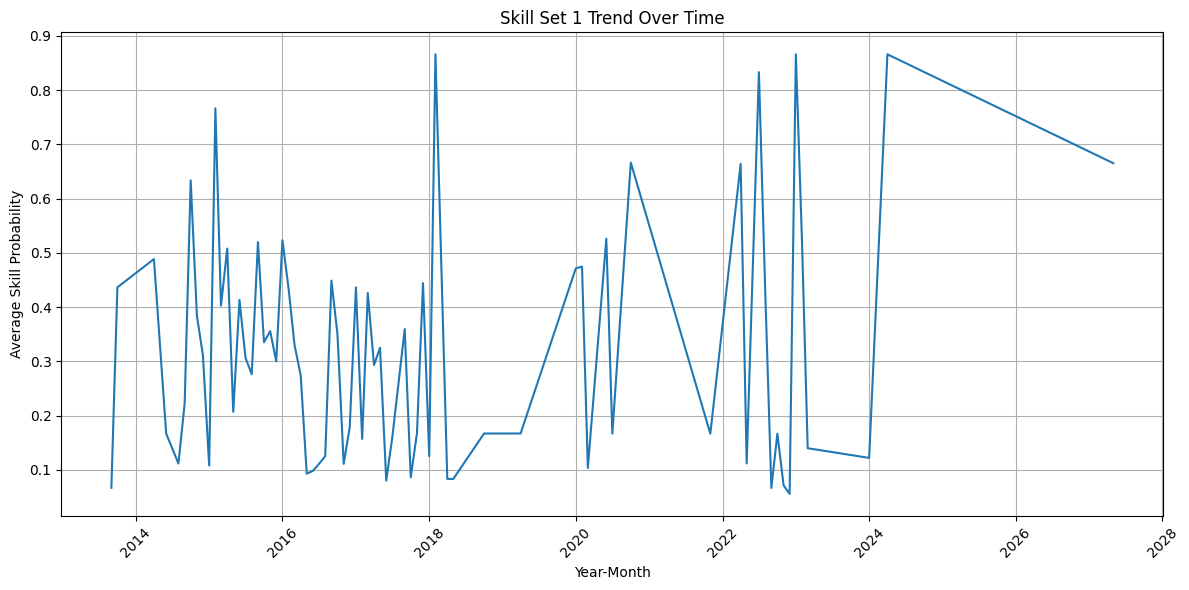

In [32]:
# Skill Set 1
plt.figure(figsize=(12, 6))
plt.plot(skill_trends.index, skill_trends['skill_set_1'])
plt.title("Skill Set 1 Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Average Skill Probability")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


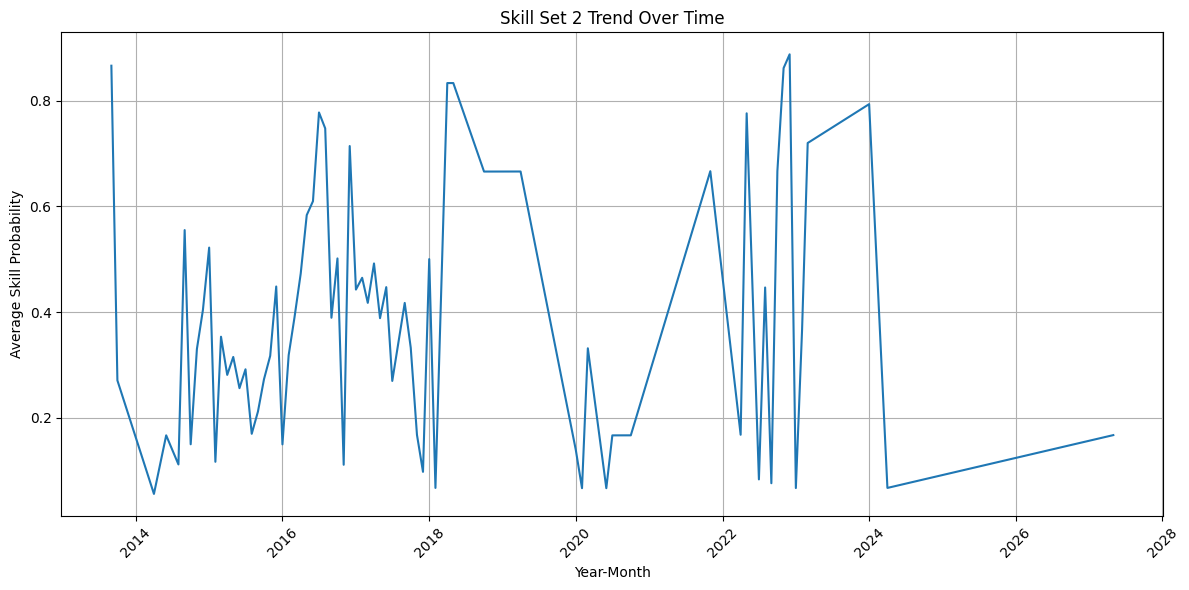

In [33]:
# Skill Set 2
plt.figure(figsize=(12, 6))
plt.plot(skill_trends.index, skill_trends['skill_set_2'])
plt.title("Skill Set 2 Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Average Skill Probability")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# Saving final USA JOBS data
usa_jobs_subset.to_csv("usa_jobs_subset.csv", index=False)

## Embeded Modeling

In [35]:
# Getting the dictionary of words from LDA Model
feature_names = vectorizer.get_feature_names_out()

# Importing Topic Keywords from LDA
topic_keywords = get_topic_keywords(lda_model, feature_names, n_top_words=5)
topic_keywords

{0: 'aviation safety nurse management operations',
 1: 'supervisory engineer service scientist human',
 2: 'physician medical technician care support'}

In [36]:
# Getting the skill text from the topic keywords in LDA
usa_jobs_subset["skill_text"] = usa_jobs_subset.apply(build_skill_text, axis=1)
usa_jobs_subset.head()

,positionOpenDate,positionTitle,appointmentType,maximumSalary,workSchedule,salaryType,state,clean_positionTitle,skill_set_0,skill_set_1,skill_set_2,year_month,skill_text
0,2020-07-22,BUDGET ANALYST,Permanent,70843.0,Full-time,Per Year,North Carolina,budget,0.666335,0.166842,0.166823,2020-07,aviation safety nurse management operationsavi...
1,2013-09-11,Attorney and Assistant United States Attorney,Multiple,129517.0,Full-time,Per Year,District of Columbia,attorney united states attorney,0.067013,0.066984,0.866004,2013-09,physician medical technician care supportphy...
2,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,District of Columbia,information technology data network,0.458469,0.474677,0.066854,2020-02,aviation safety nurse management operationsavi...
3,2020-02-14,SENIOR INFORMATION TECHNOLOGY SPECIALIST (DATA...,Permanent,115742.0,Full-time,Per Year,District of Columbia,information technology data network,0.458469,0.474677,0.066854,2020-02,aviation safety nurse management operationsavi...
4,2018-02-15,Rating Veterans Service Representative,Agency Employees Only,0.0,Full-time,Per Year,Mississippi,rating veterans service representative,0.066846,0.865790,0.067364,2018-02,supervisory engineer service scientist humans...


In [37]:
# Embedded Modeling
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Loading the a pre-trained all-MiniLM-L6-v2 embedding model
embedded_model = SentenceTransformer('all-MiniLM-L6-v2')

#Encoding Labels
embeddings = embedded_model.encode(
    usa_jobs_subset["skill_text"].fillna("").tolist(),
    convert_to_tensor=True
)
embeddings_cpu = embeddings.detach().cpu().numpy()
usa_jobs_subset["skill_embedding"] = embeddings_cpu.tolist()

# Computing similarity between first label and all other labels
similarities = cosine_similarity(
    embeddings[0].detach().cpu().numpy().reshape(1, -1),
    embeddings.detach().cpu().numpy()
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

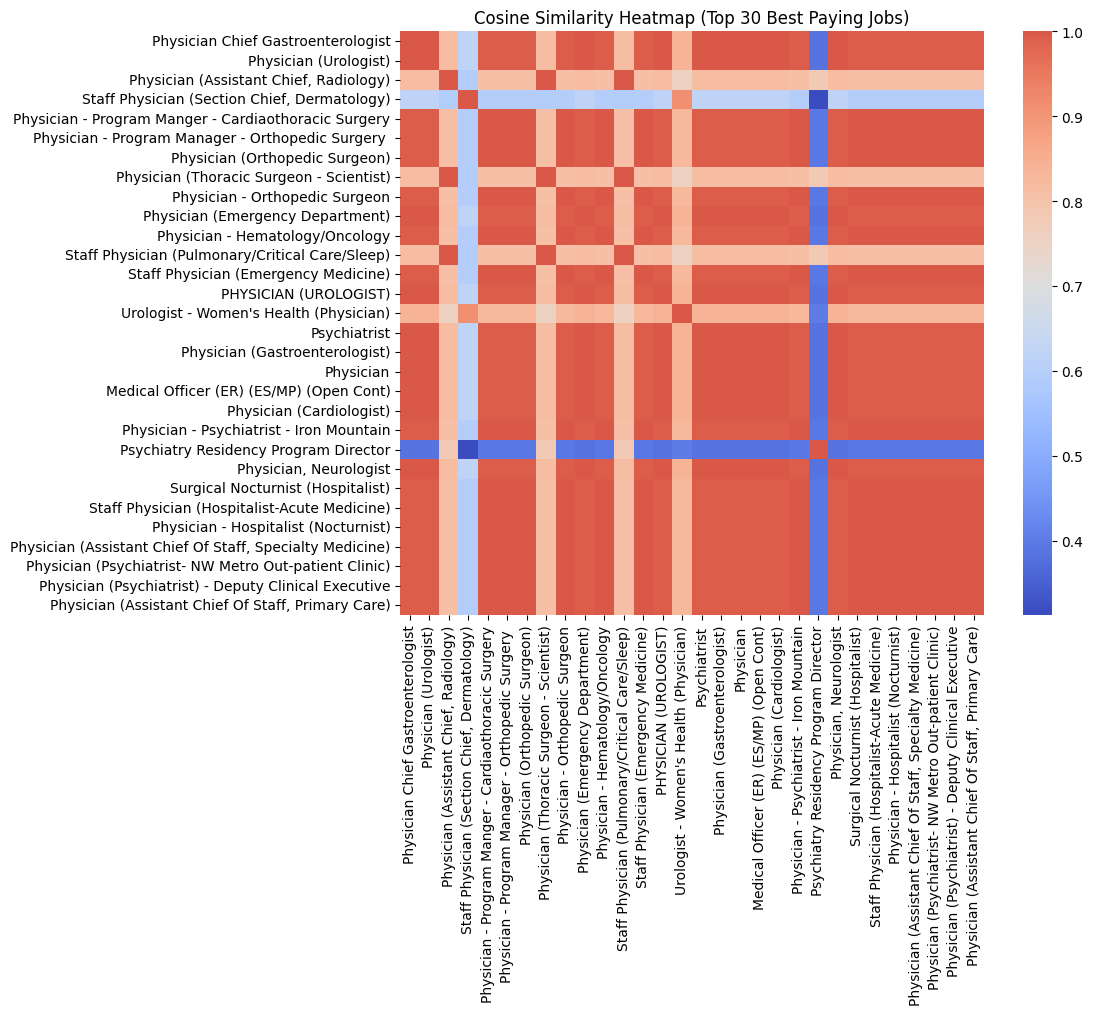

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Removing duplicated positions
usa_jobs_unique = usa_jobs_subset.drop_duplicates(subset='positionTitle')

# Filtering for top 30 best paying jobs
top_jobs = usa_jobs_unique.sort_values(by="maximumSalary", ascending=False).head(30)

# Converting embeddings into a array
embeddings_subset = np.vstack(top_jobs["skill_embedding"].values)

# Computing Cosine Similarity Matrix
similarity_subset = cosine_similarity(embeddings_subset)

# Heat Map
job_labels = top_jobs['positionTitle'].values

plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_subset,
    xticklabels=job_labels,
    yticklabels=job_labels,
    cmap="coolwarm",
    center=0.7,
    square=True
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Cosine Similarity Heatmap (Top 30 Best Paying Jobs)")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


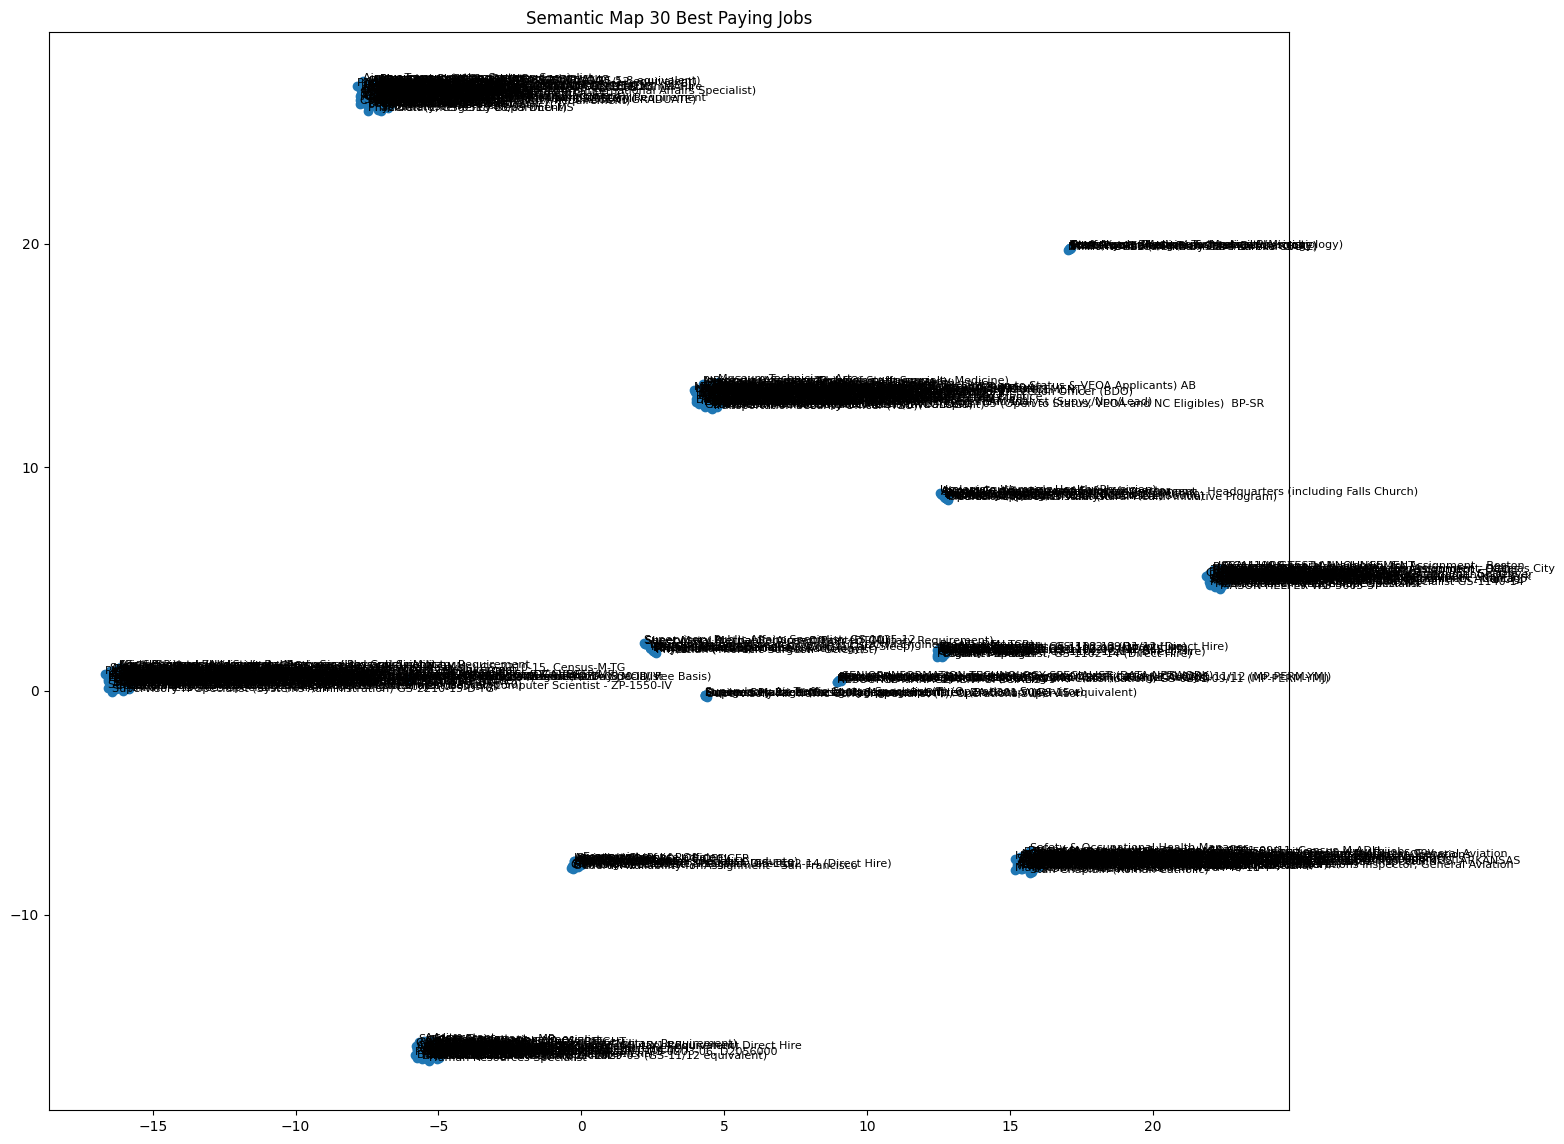

In [39]:
# Semantic Map
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.2,
    metric='cosine',
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings.detach().cpu().numpy())


plt.figure(figsize=(16, 14))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1])

for i, label in enumerate(usa_jobs_subset['positionTitle']):
    plt.annotate(label, (embedding_2d[i, 0], embedding_2d[i, 1]), fontsize=8)

plt.title("Semantic Map 30 Best Paying Jobs")
plt.show()

In [40]:
# Clustering the jobs by embeddings and similarities in topics
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
usa_jobs_subset['Skill Demand Clusters'] = kmeans.fit_predict(
    embeddings.detach().cpu().numpy()
)



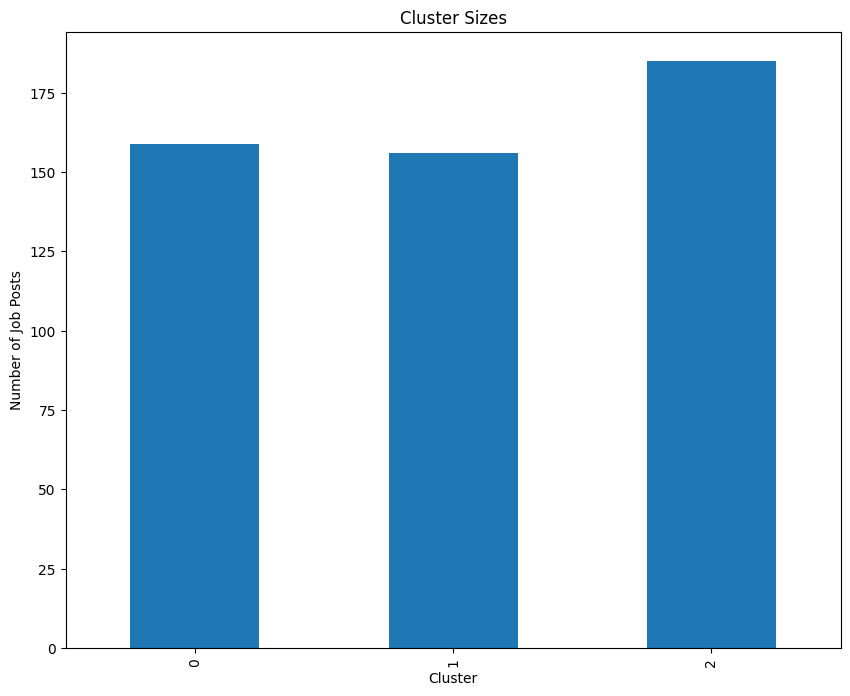

In [41]:
# Plotting Clusters
import pandas as pd

cluster_counts = pd.Series(usa_jobs_subset['Skill Demand Clusters']).value_counts().sort_index()

cluster_counts.plot(kind='bar', figsize=(10, 8))
plt.xlabel("Cluster")
plt.ylabel("Number of Job Posts")
plt.title("Cluster Sizes")
plt.show()

In [42]:
# Converting Skill Demand Clusters into Category Type
usa_jobs_subset['Skill Demand Clusters'] = usa_jobs_subset['Skill Demand Clusters'].astype('category')


In [43]:
# Getting the averages for the skill sets across each of the clusters
cluster_skill_summary = (
    usa_jobs_subset
    .groupby('Skill Demand Clusters')[['skill_set_0', 'skill_set_1', 'skill_set_2']]
    .mean()
    .reset_index()
)
cluster_skill_summary

/tmp/ipykernel_216/1526632682.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Skill Demand Clusters')[['skill_set_0', 'skill_set_1', 'skill_set_2']]


,Skill Demand Clusters,skill_set_0,skill_set_1,skill_set_2
0,0,0.111313,0.770370,0.118317
1,1,0.676366,0.157676,0.165959
2,2,0.110621,0.130044,0.759335


# Comparison Case I: Federal and Local Government Case from Payroll Data

## Natural Language Processing (NLP), Topic Modelling and Embedded Modelling for Payroll Data

In [44]:
# Cleaning Text Data
payroll_df['CLEAN_AGG_DESC_LABEL'] = payroll_df['AGG_DESC_LABEL'].apply(fxn_clean_text)

In [45]:
# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Converting text to bag-of-words format
vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(payroll_df['CLEAN_AGG_DESC_LABEL'])

# Fitting LDA model for 3 topics
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(bow)

# Function for getting overview of resultant topics
def fxn_display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print({topic_idx},":", [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]])

# Getting topics for all the job titles
fxn_display_topics(lda_model, vectorizer.get_feature_names_out(), 5)


{0} : ['education', 'higher', 'secondary', 'elementary', 'instructional']
{1} : ['fire', 'protection', 'administration', 'waste', 'solid']
{2} : ['protection', 'police', 'power', 'government', 'supply']


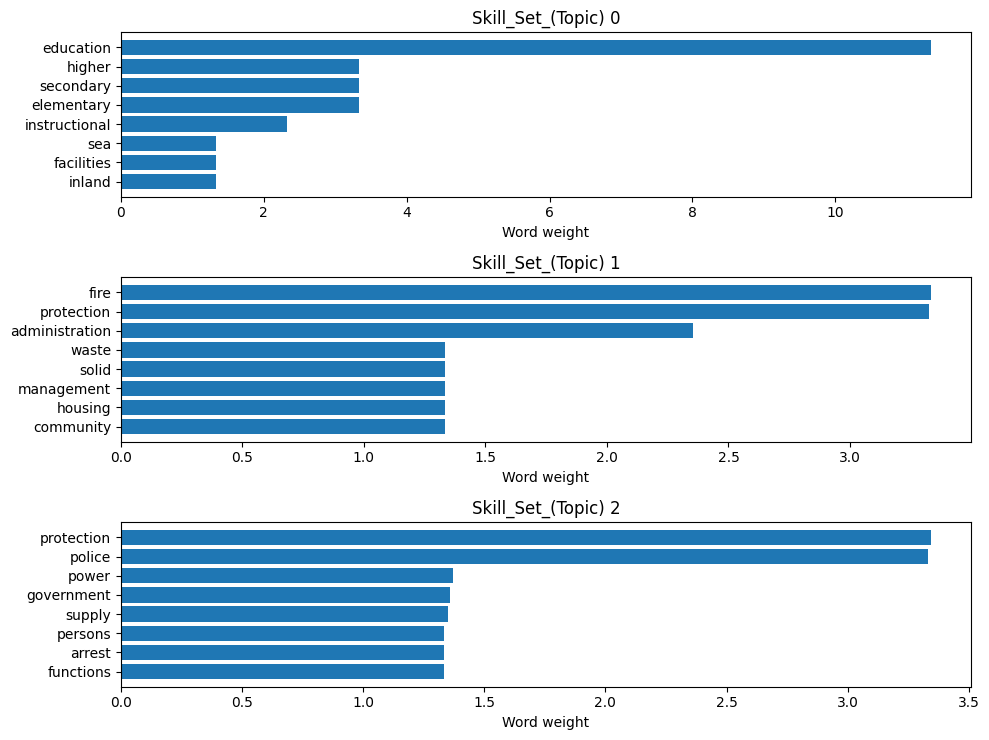

In [46]:
# Plotting LDA topic
fxn_plot_lda_topics(lda_model, vectorizer.get_feature_names_out())


# Comparison Case II: New York City Data

### Natural Language Processing (NLP)

In [47]:
# Cleaning Text Data
city_df['clean_title_description'] = city_df['title_description'].apply(fxn_clean_text)

### Topic Modeling

In [49]:
# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Converting text to bag-of-words format
vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(city_df['clean_title_description'])

# Fitting LDA model for 3 topics
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(bow)

# Function for getting overview of resultant topics
def fxn_display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print({topic_idx},":", [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]])

# Getting topics for all the job titles
fxn_display_topics(lda_model, vectorizer.get_feature_names_out(), 5)

{0} : ['operations', 'development', 'clerical', 'mayoral', 'executive']
{1} : ['administrative', 'social', 'community', 'care', 'project']
{2} : ['protective', 'welfare', 'protection', 'evaluator', 'caseworker']


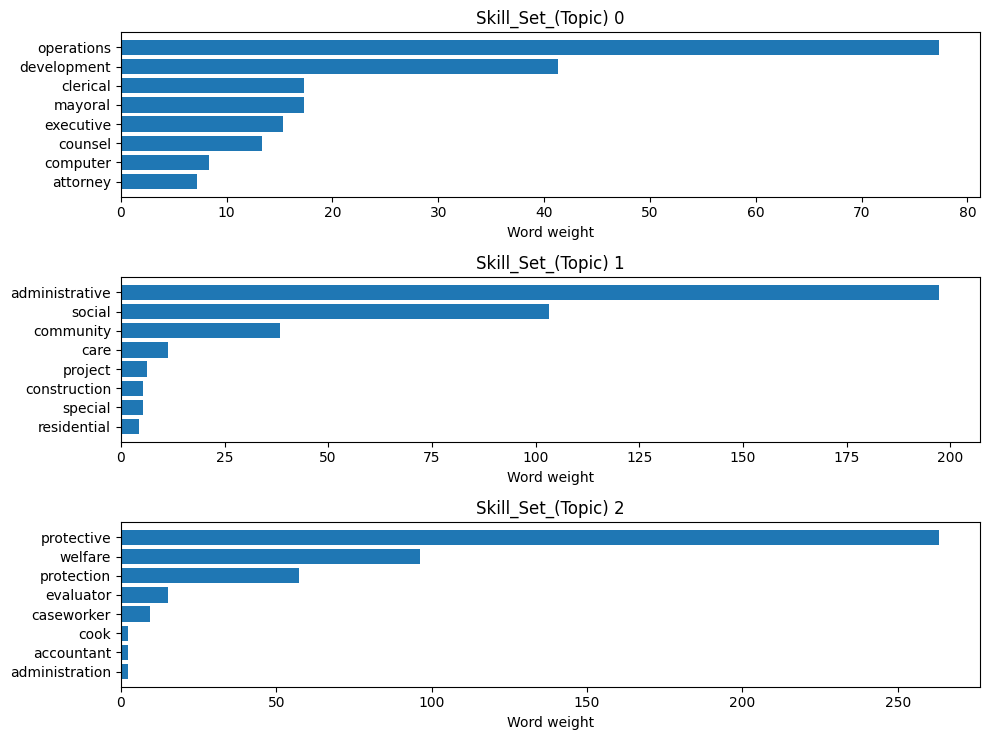

In [50]:
# Plotting LDA topic
fxn_plot_lda_topics(lda_model, vectorizer.get_feature_names_out())